In [5]:
#import packages
import sys
#sys.path.insert(0, '/soft/python3/usr/local/lib64/python3.9/site-packages') #import default cluster packages
#sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #import custom packages
import numpy as np
import matplotlib.pyplot as plt
import astropy 
import scipy
import astropy.units as u
from scipy.constants import year as yr
from astropy.constants import M_sun
from astropy.constants import c
from astropy.constants import L_sun
import astropy.cosmology.units as cu
from astropy.cosmology import Planck18 as cosmo
from astropy.constants import L_sun
L_sun_eps = L_sun.cgs.value
#plotsdir = "/mnt/home/kprofit/plots/"
plotsdir = "/beegfs/general/kprofit/analysis_scripts"
run_dir = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin/blackhole_details/"
run_dir2 = "/beegfs/general/skoudmani/binary_proj/adios_runs/production_binary/misal_td/output_bhspin/blackhole_details/"

In [6]:
details_file = "bh1_details.dat"
spin_file = "bh1_bhspin.dat"
details_file2 = "bh2_details.dat"
spin_file2 = "bh2_bhspin.dat"
spin_data = np.loadtxt(run_dir+spin_file)
bh_data = np.loadtxt(run_dir+details_file)
bh_data2 = np.loadtxt(run_dir2+details_file2)
spin_data2 = np.loadtxt(run_dir2+spin_file2)
time = spin_data[:,0][:9001] * 0.978462
spin = spin_data[:,3][:9001]
time2 = spin_data2[:,0][:9001]
spin2 = spin_data2[:,3][:9001]
mass = bh_data[:,1][:9001]
mass2 = bh_data2[:,1][:9001]

mdot = bh_data[:,2][:9001]
mdot2 = bh_data2[:,2][:9001]
mdot_Msunyr = mdot * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
mdot_cgs = mdot * (unitmass_in_g) / (unittime_in_s)
mdot_cgs2 = mdot2 * (unitmass_in_g) / (unittime_in_s)#to convert to cgs units
mdot_Msunyr2 = mdot2 * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1

In [7]:
#Load in the code units from the simulation snapshot.

import sys
sys.path.insert(0, '/soft/python3/usr/local/lib64/python3.9/site-packages') #import default cluster packages
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #import custom packages
#sys.path.insert(0, '/mnt/home/skoudmani/for_kasar/python_scripts/')
import read_snap_files as rsf
snap_dir_orig = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin"
snap_name = rsf.get_snap_filename(snap_dir_orig, 100, snap_prefix="snapshot")
unitlength_in_cm = rsf.get_attribute(snap_name, "UnitLength_in_cm", param=True) #How much one 'code length unit' is in cm
unitmass_in_g = rsf.get_attribute(snap_name, "UnitMass_in_g", param=True)  #How much one 'code mass unit' is in grams
unitvelocity_in_cm_per_s = rsf.get_attribute(snap_name, "UnitVelocity_in_cm_per_s", param=True)  #How much one 'code velocity unit' is in cm per second
unittime_in_s = unitlength_in_cm / unitvelocity_in_cm_per_s   #How much one 'code time unit' is in seconds

#Convert M_dot units 

from astropy.constants import M_sun

mass = bh_data[:,1][:9001]
mass2 = bh_data2[:,1][:9001]
mdot_Msunyr = mdot * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
mdot_cgs = mdot * (unitmass_in_g) / (unittime_in_s)
mdot_cgs2 = mdot2 * (unitmass_in_g) / (unittime_in_s)#to convert to cgs units
mdot_Msunyr2 = mdot2 * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
M_sunyr = M_sun / (unittime_in_s / (365*24*3600))

#print(M_sunyr)

#convert mass units
mass_Msun = mass * (unitmass_in_g / M_sun.cgs.value) #to convert to Msun 
mass_cgs = mass * (unitmass_in_g) 
mass_cgs2 = mass2 * (unitmass_in_g)#to convert to cgs units
mass_Msun2 = mass2 * (unitmass_in_g / M_sun.cgs.value) #to convert to Msun 
print(mass_Msun)
print(mass_Msun2)

[999296.64635111 999296.64635111 999296.64635111 ... 999613.1033197
 999613.1033197  999613.1033197 ]
[499648.32317555 499648.32317555 499648.32317555 ... 499892.64657042
 499892.64657042 499892.64657042]


In [8]:
#Constants Cell 

a = np.linspace(0.0,1,100)
bol_correction_radio = 0.1 
q = [1,3]
f = 1 
g = 2.3 
m9 = [mass_Msun / (10**9), mass_Msun2 / (10**9)]
m_jet = [mdot_Msunyr / (22 * m9[0] ), mdot_Msunyr2 / (22 * m9[1])]
#nu_SKA = 1.7 #typical frequency which bulk emission is expected
F_telescope_SKA = [2.1*10**-17]


In [9]:
#Functions Cell

def z1(a):
    return 1 + (1 - a**2)**(1/3)*(1+a)**(1/3)+(1-a)**(1/3) #Function of spin a
def z2(a):
    return np.sqrt(3*a**2 + z1(a)**2) #Function of spin a
def Lam(a):
    Lam1 = 3 + z2(a) - np.sqrt((3-z1(a))*(3+z1(a)+2*z2(a))) #Lambda in prograde
    Lam2 = 3 + z2(a) + np.sqrt((3-z1(a))*(3+z1(a)+2*z2(a))) #Lambda in retrograde
    return Lam1,Lam2
def eta(a,corotating=True): 
    Lam1,Lam2 = Lam(a)
    eta1 = 1 - np.sqrt(1-(2/(3*Lam1)))
    eta2 = 1 - np.sqrt(1-(2/(3*Lam2))) #Radiative effeciency 
    if corotating:
        return eta1 
    else:
        return eta2
    
def calculate_luminosities(a,mdot_cgs): 
    c_light_cgs = c.cgs.value 
    rad_eff = eta(a)[:9001]
    #print(np.shape(rad_eff))
    #print(np.shape(mdot_cgs))
    L = rad_eff * mdot_cgs * c_light_cgs**2
    return L

c_light_cgs = c.cgs.value 
luminosities = calculate_luminosities(spin ,mdot_cgs)
luminosities2 = calculate_luminosities(spin2 ,mdot_cgs2)

def get_bol_correction(bol_lum,c1,c2,k1,k2):
    Lum_band = (bol_lum) / ((c1*(bol_lum/((10**10)*L_sun_eps))**k1)) + ((c2*(bol_lum/((10**10)*L_sun_eps))**k2))
    return Lum_band

#Calculate flare luminosity
def get_flare_lum(bol_lum,bol_correction_radio,q):
    flare_lum = (bol_lum * bol_correction_radio) / q**2
    return flare_lum 

#Calculate Jet Luminosity
def get_jet_lum(m9,m_jet,a,f,g):
    jet_lum = 3 * 10**45.1 * m9 * (m_jet/0.1) * g**2 * (((0.55*f)**2) + (1.5*f*a) + (a**2))
    return jet_lum

#Calculate Jet Luminosity (high Eddington Limit)
def get_jet_lum_high(m9,m_jet,a):
    jet_lum_high = (0.8 * 10**42.7) * (m9**0.9) * ((m_jet/0.1)**(6/5)) * (1+(1.1*a)+(0.29*a**2))
    return jet_lum_high

#Calculate luminosity distance
z = np.linspace(0.0,15,100)

def calculate_lum_dist(z):
    lum_dist = cosmo.luminosity_distance(z) * (3.086*10**24) 
    #here lum_dist is a local variable, it will only be available to the 'outside' code by calling the function
    return lum_dist
lum_dist = calculate_lum_dist(z) #call the function and save the result to the global variable lum_dist

#Calculate Detectable Luminosity
def calculate_L_detectable(lum_dist, F_telescope):
    L_detectable = (F_telescope) * (4 * np.pi * lum_dist**2)
    return L_detectable

In [23]:
##Load in txt files for details on BH and BH spin
run_dir = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin/blackhole_details/"
run_dir2 = "/beegfs/general/skoudmani/binary_proj/adios_runs/production_binary/misal_td/output_bhspin/blackhole_details/"
details_file = "bh1_details.dat"
spin_file = "bh1_bhspin.dat"
details_file2 = "bh2_details.dat"
spin_file2 = "bh2_bhspin.dat"
spin_data = np.loadtxt(run_dir+spin_file)
bh_data = np.loadtxt(run_dir+details_file)
bh_data2 = np.loadtxt(run_dir2+details_file2)
spin_data2 = np.loadtxt(run_dir2+spin_file2)
time = spin_data[:,0][:9001] * 0.978462
spin = spin_data[:,3][:9001]
time2 = spin_data2[:,0][:9001]
spin2 = spin_data2[:,3][:9001]
mass = bh_data[:,1][:9001]
mass2 = bh_data2[:,1][:9001]

print(mass)
print(mass2)

colors = ["blue", "green", "black"]
titles = ["q=1", "q=3"]

[4294.56 4294.56 4294.56 ... 4295.92 4295.92 4295.92]
[2147.28 2147.28 2147.28 ... 2148.33 2148.33 2148.33]


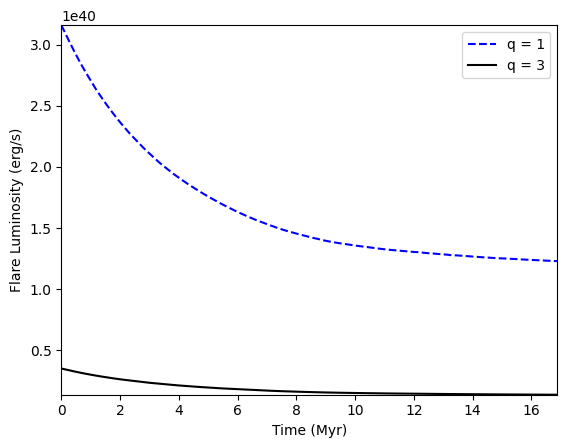

In [11]:
#Plot Flare luminosity

q1 = get_flare_lum(luminosities,bol_correction_radio,q[0])
q3 = get_flare_lum(luminosities,bol_correction_radio,q[1])

plt.plot(time,q1,'b--', label='q = 1')
plt.plot(time,q3,'k',label='q = 3')
plt.ylabel('Flare Luminosity (erg/s)')
plt.xlabel('Time (Myr)')
plt.margins(x=0)
plt.margins(y=0)
plt.legend()

9001
(9001,)
(2, 9001)
(2, 9001)


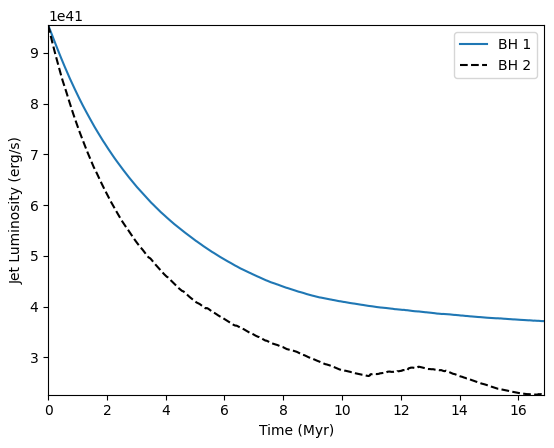

In [12]:
#Plot Jet Luminosity

jet_lum_1 = get_jet_lum(m9[0],m_jet[0],spin,f,g)
jet_lum_2 = get_jet_lum(m9[1],m_jet[1],spin2,f,g)
jet_lum_3 = jet_lum_1 + jet_lum_2

print(len(jet_lum_1))
print(np.shape(jet_lum_1))
print(np.shape(m9))
print(np.shape(m_jet))


plt.plot(time,jet_lum_1, label = 'BH 1')
plt.plot(time,jet_lum_2, 'k--', label = 'BH 2')
plt.ylabel('Jet Luminosity (erg/s)')
plt.xlabel('Time (Myr)')
plt.margins(x=0)
plt.margins(y=0)
plt.legend()


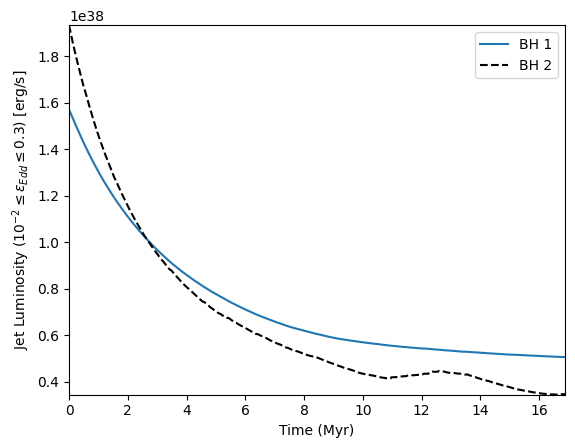

In [13]:
#Plot Jet Luminosity high Eddington limit

jet_lum_high_1 = get_jet_lum_high(m9[0],m_jet[0],spin)
jet_lum_high_2 = get_jet_lum_high(m9[1],m_jet[1],spin2)
jet_lum_high_3 = jet_lum_high_1 + jet_lum_high_2

plt.plot(time,jet_lum_high_1, label = 'BH 1')
plt.plot(time,jet_lum_high_2, 'k--', label = 'BH 2')

plt.ylabel('Jet Luminosity ($10^{-2} \leq \epsilon_{Edd} \leq 0.3)$ [erg/s]')
plt.xlabel('Time (Myr)')
plt.margins(x=0)
plt.margins(y=0)
plt.legend()

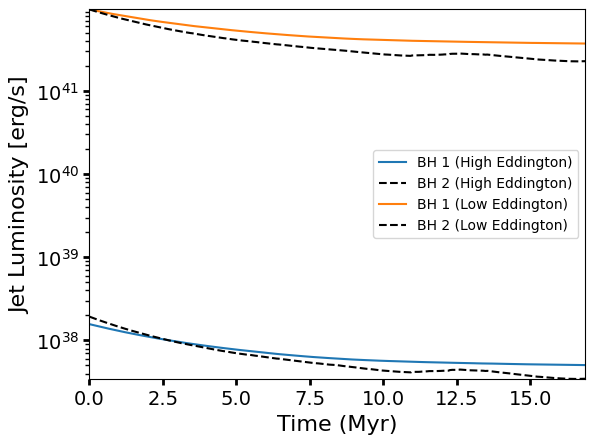

In [14]:
#Plot Jet Luminosity high and low Eddington Regime

jet_lum_high_1 = get_jet_lum_high(m9[0],m_jet[0],spin)
jet_lum_high_2 = get_jet_lum_high(m9[1],m_jet[1],spin2)
jet_lum_high_3 = jet_lum_high_1 + jet_lum_high_2

plt.plot(time,jet_lum_high_1, label = 'BH 1 (High Eddington)')
plt.plot(time,jet_lum_high_2, 'k--', label = 'BH 2 (High Eddington)')
plt.plot(time,jet_lum_1, label = 'BH 1 (Low Eddington)')
plt.plot(time,jet_lum_2, 'k--', label = 'BH 2 (Low Eddington)')
plt.ylabel('Jet Luminosity [erg/s]',fontsize=16)
plt.xlabel('Time (Myr)',fontsize=16)
plt.tick_params(direction='out',which = 'major', length=4, width=2, labelsize=14)
plt.tick_params(direction='out',which = 'minor', length=3, width=1)
plt.yscale("log")
plt.margins(x=0)
plt.margins(y=0)
plt.legend()

plt.savefig("%s/Jet_Lum_Edd.png" %plotsdir,bbox_inches='tight')

In [15]:
#Mean and Max Jet luminosity 

#print(np.mean(jet_lum_1))
#print(np.mean(jet_lum_2))
#print(np.max(jet_lum_1))
#print(np.max(jet_lum_2))

x = ((4*np.pi)*(1.7*10**9)*(9.9*10**-28))
y = (10**-34) * (10**7)
print(x)

2.114920174396649e-17


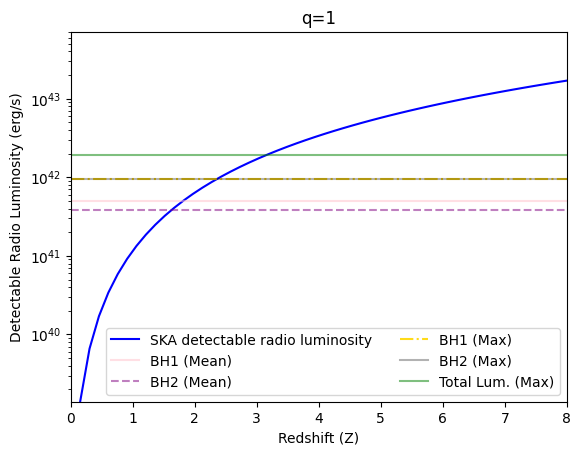

In [16]:
#SKA detectable Luminosity 

SKA = calculate_L_detectable(lum_dist,F_telescope_SKA)

plt.plot(z,SKA, 'b', label='SKA detectable radio luminosity')
plt.ylabel("Detectable Radio Luminosity (erg/s)")
plt.xlabel("Redshift (Z)")
plt.title("q=1")
plt.yscale("log")
plt.xlim(0,8)
plt.margins(x=0)
plt.margins(y=0)


plt.axhline(y=np.mean(jet_lum_1), color='pink', linestyle='-', label='BH1 (Mean)',alpha=0.5)
plt.axhline(y=np.mean(jet_lum_2), color='purple', linestyle='--', label='BH2 (Mean)',alpha=0.5)
plt.axhline(y=np.max(jet_lum_1), color='gold', linestyle='-.', label='BH1 (Max)', alpha=0.9)
plt.axhline(y=np.max(jet_lum_2), color='k', linestyle='-', label='BH2 (Max)', alpha=0.3)
plt.axhline(y=np.max(jet_lum_3), color='g', linestyle='-', label='Total Lum. (Max)',alpha=0.5)

plt.legend(loc=4, prop={'size': 10}, ncol=2)

#plt.savefig("%s/Radio_Detectable_Lum1.png" %plotsdir,bbox_inches='tight')

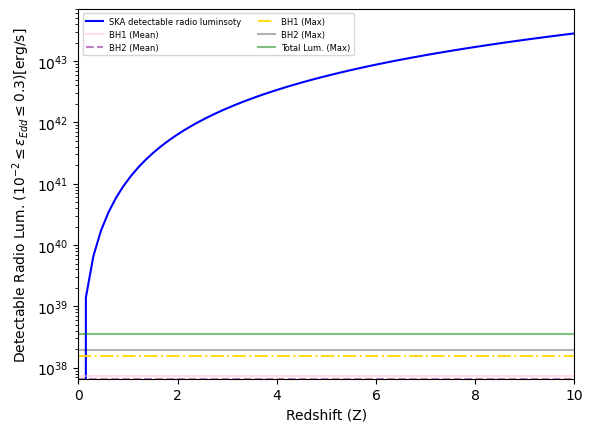

In [17]:
#SKA detectable Luminosity w/ high Eddingtin fraction

plt.plot(z,SKA, 'b', label='SKA detectable radio luminsoty')
plt.ylabel("Detectable Radio Lum. ($10^{-2} \leq \epsilon_{Edd} \leq 0.3$)[erg/s]")
plt.xlabel("Redshift (Z)")
plt.yscale("log")
plt.xlim(0,10)
plt.margins(x=0)
plt.margins(y=0)

plt.axhline(y=np.mean(jet_lum_high_1), color='pink', linestyle='-', label='BH1 (Mean)',alpha=0.5)
plt.axhline(y=np.mean(jet_lum_high_2), color='purple', linestyle='--', label='BH2 (Mean)',alpha=0.5)
plt.axhline(y=np.max(jet_lum_high_1), color='gold', linestyle='-.', label='BH1 (Max)', alpha=0.9)
plt.axhline(y=np.max(jet_lum_high_2), color='k', linestyle='-', label='BH2 (Max)', alpha=0.3)
plt.axhline(y=np.max(jet_lum_high_3), color='g', linestyle='-', label='Total Lum. (Max)',alpha=0.5)

plt.legend(loc=0, prop={'size': 6}, ncol=2)

0
4.9933162198157136e+41
3.845181430016234e+41
1.9095835478303734e+42
1
6.383507315769147e+41
3.845181430016234e+41
1.9095835478303734e+42


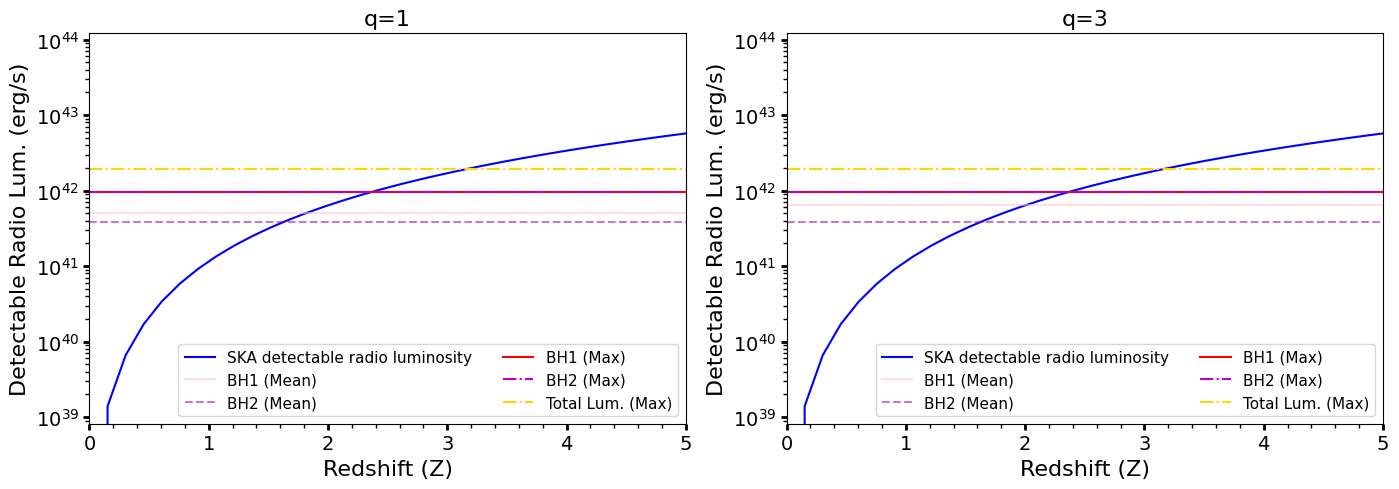

In [24]:
#Make subplots for different mass ratios for detecable radio luminosity

plt.figure(figsize=(21, 5))
plt.subplots_adjust()
#plt.suptitle("Radio Telescope Detectable Luminosity", fontsize=18, y=0.95)

#loop through the length of tickers and keep track of index
for i, run_dir in enumerate([run_dir, run_dir2]):
    print(i)
    #Load in data
    spin_data = np.loadtxt(run_dir+spin_file)
    bh_data = np.loadtxt(run_dir+details_file)
    bh_data2 = np.loadtxt(run_dir2+details_file2)
    spin_data2 = np.loadtxt(run_dir2+spin_file2)
    time = spin_data[:,0][:9001] * 0.978462
    spin = spin_data[:,3][:9001]
    time2 = spin_data2[:,0][:9001]
    spin2 = spin_data2[:,3][:9001]
    efficiency = eta(spin, corotating=True)
    efficiency2 = eta(spin2, corotating=True)
    
    mdot = bh_data[:,2][:9001]
    mdot2 = bh_data2[:,2][:9001]
    mdot_Msunyr = mdot * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
    mdot_cgs = mdot * (unitmass_in_g) / (unittime_in_s)
    mdot_cgs2 = mdot2 * (unitmass_in_g) / (unittime_in_s)#to convert to cgs units
    mdot_Msunyr2 = mdot2 * (unitmass_in_g / M_sun.cgs.value) / (unittime_in_s / (365*24*3600)) #to convert to Msun yr-1
    
    mass = bh_data[:,1][:9001]
    mass2 = bh_data2[:,1][:9001]
    
    mass_Msun = mass * (unitmass_in_g / M_sun.cgs.value) #to convert to Msun 
    mass_Msun2 = mass2 * (unitmass_in_g / M_sun.cgs.value) #to convert to Msun 
    
    m9 = [mass_Msun / (10**9), mass_Msun2 / (10**9)]
    m_jet = [mdot_Msunyr / (22 * m9[0] ), mdot_Msunyr2 / (22 * m9[1])]
    
    #calculate radio luminsoities
    luminosities = calculate_luminosities(spin ,mdot_cgs)
    luminosities2 = calculate_luminosities(spin2 ,mdot_cgs2)

    #xray_h1 = get_bol_correction(luminosities,c1[1],c2[1],k1[1],k2[1])
    #xray_s1 = get_bol_correction(luminosities,c1[0],c2[0],k1[0],k2[0])
    #xray_h2 = get_bol_correction(luminosities2,c1[1],c2[1],k1[1],k2[1])
    #xray_s2 = get_bol_correction(luminosities2,c1[0],c2[0],k1[0],k2[0])
    
    #xray_1 = get_bol_correction_avg(luminosities,c1_avg,c2_avg,k1_avg,k2_avg)
    #xray_2 = get_bol_correction_avg(luminosities2,c1_avg,c2_avg,k1_avg,k2_avg)
    
    jet_lum_1 = get_jet_lum(m9[0],m_jet[0],spin,f,g)
    jet_lum_2 = get_jet_lum(m9[1],m_jet[1],spin2,f,g)
    jet_lum_high_3 = jet_lum_high_1 + jet_lum_high_2
    
    # add a new subplot iteratively
    ax = plt.subplot(1, 3, i + 1)
    ax.plot(z,SKA, 'b', label='SKA detectable radio luminosity')
    ax.set_title(titles[i],fontsize=16)
    plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
    
    ax.legend(loc=1)
    ax.set_title(titles[i],fontsize=16)
    
    #Plot horizontal line for mean luminosity of each binary
    print(np.mean(jet_lum_1))
    print(np.mean(jet_lum_2))
    print(np.max(jet_lum_3))
    
    ax.axhline(y=np.mean(jet_lum_1), color='pink', linestyle='-', label='BH1 (Mean)',alpha=0.5)
    ax.axhline(y=np.mean(jet_lum_2), color='purple', linestyle='--', label='BH2 (Mean)',alpha=0.5)
    ax.axhline(y=np.max(jet_lum_1), color='r', linestyle='-', label='BH1 (Max)')
    ax.axhline(y=np.max(jet_lum_2), color='m', linestyle='-.', label='BH2 (Max)')
    ax.axhline(y=np.max(jet_lum_3), color='gold', linestyle='-.', label='Total Lum. (Max)')
    #ax.axvline(0.5)
    ax.legend(loc=4, prop={'size': 11}, ncol=2)
    
    #chart formatting
    ax.set_yscale("log")
    ax.margins(x=0)
    plt.style.context('bmh')
    ax.tick_params(direction='out',which = 'major', length=4, width=2, labelsize=14)
    ax.tick_params(direction='out',which = 'minor', length=3, width=1)
    ax.set_xlabel("Redshift (Z)",fontsize=16)
    ax.set_ylabel("Detectable Radio Lum. (erg/s)",fontsize=16)
    ax.set_xlim(0,5)
    plt.tight_layout()
    ax.minorticks_on()
    plt.savefig("%s/Radio_Detectable_Lum.png" %plotsdir,bbox_inches='tight')